<a href="https://colab.research.google.com/github/LarsVoermans/master-thesis-pead/blob/main/Logistic_regression_3class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All imports
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()  # er verschijnt een knop om bestanden te kiezen

Saving test_feature_engineered.parquet to test_feature_engineered (1).parquet
Saving train_feature_engineered.parquet to train_feature_engineered (1).parquet
Saving val_feature_engineered.parquet to val_feature_engineered (1).parquet


In [ ]:
#Loading the dataset
train = pd.read_parquet("train_feature_engineered.parquet")
val = pd.read_parquet("val_feature_engineered.parquet")

In [ ]:

#All the price features which include values as medium and medium_low
valuation_features = [
    'Shillers Cyclically Adjusted P/E Ratio',
    'Enterprise Value Multiple',
    'Price/Book',
    'Price/Sales',
    'Price/Cash flow',
    'Price/Operating Earnings (Basic, Excl. EI)',
    'Price/Operating Earnings (Diluted, Excl. EI)',
    'P/E (Diluted, Excl. EI)',
    'P/E (Diluted, Incl. EI)',
    'Trailing P/E to Growth (PEG) ratio',
    'Book/Market',
    'Dividend Yield',
    'Dividend Payout Ratio'
]

# Select _Regime columns
regime_cols = [f"{col}_Regime" for col in valuation_features if f"{col}_Regime" in train.columns]

# Convert to string
for col in regime_cols:
    train[col] = train[col].astype(str)
    val[col] = val[col].astype(str)

# Missing values
for col in regime_cols:
    train[col] = train[col].replace("nan", "Missing")
    val[col] = val[col].replace("nan", "Missing")

# One-hot encoding (
train = pd.get_dummies(train, columns=regime_cols, drop_first=True)
val = pd.get_dummies(val, columns=regime_cols, drop_first=True)

# Align val and test on train columns
val = val.reindex(columns=train.columns, fill_value=0)


In [ ]:
#making 3 class return
# Train
conditions_train = [
    (train['Return'] > 3),
    (train['Return'] >= -3) & (train['Return'] <= 3),
    (train['Return'] < -3)
]

choices = [1, 0, -1]

train['Return_class_3'] = np.select(conditions_train, choices, default=np.nan)


# Validation
conditions_val = [
    (val['Return'] > 3),
    (val['Return'] >= -3) & (val['Return'] <= 3),
    (val['Return'] < -3)
]

val['Return_class_3'] = np.select(conditions_val, choices, default=np.nan)

print("--- Train distribution (3-class) ---")
print(train['Return_class_3'].value_counts())
print(train['Return_class_3'].value_counts(normalize=True))

print("\n--- Validation distribution (3-class) ---")
print(val['Return_class_3'].value_counts())
print(val['Return_class_3'].value_counts(normalize=True))


--- Train distribution (3-class) ---
Return_class_3
 0.0    5749
 1.0    1728
-1.0    1551
Name: count, dtype: int64
Return_class_3
 0.0    0.636797
 1.0    0.191405
-1.0    0.171799
Name: proportion, dtype: float64

--- Validation distribution (3-class) ---
Return_class_3
 0.0    1617
 1.0     329
-1.0     297
Name: count, dtype: int64
Return_class_3
 0.0    0.720909
 1.0    0.146679
-1.0    0.132412
Name: proportion, dtype: float64


In [ ]:
#making a return class
target = "Return"

X_train = train.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_train = train["Return_class_3"]

X_val = val.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_val = val["Return_class_3"]


In [ ]:
#dropping columns
drop_cols = [
    'CUSIP',
    'Global Company Key',
    'Historical CRSP PERMNO Link to COMPUSTAT Record',
    'Ticker',
    'Date',
    'EarningsDate',
    'Fiscal year end',
    'Fiscal quarter end',
    'Year',
    'Month'
]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])


In [ ]:
#Making imputer
imputer = SimpleImputer(strategy='mean')

# Fit on training
X_train_scaled = imputer.fit_transform(X_train)

# Transform val
X_val_scaled = imputer.transform(X_val)


In [ ]:
# stratified K-fold for logistic regression
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_list = []
macro_f1_list = []
report_list = []

# Maak lege lijsten om de Out-of-Fold (OOF) resultaten in te verzamelen
all_true_labels_lr = []
all_pred_labels_lr = []

fold = 1
for train_index, val_index in skf.split(X_train_scaled, y_train):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val_fold)

    # Zorg voor exact dezelfde datatypes (numpy arrays van integers)
    y_true_array = np.array(y_val_fold).astype(int)
    y_pred_array = np.array(y_pred).astype(int)

    # --- GEWIJZIGD: labels=[0, 1, 2] is veranderd naar labels=[-1, 0, 1] ---
    acc = accuracy_score(y_true_array, y_pred_array)
    macro_f1 = f1_score(y_true_array, y_pred_array, average='macro', labels=[-1, 0, 1])
    report = classification_report(y_true_array, y_pred_array, output_dict=True, labels=[-1, 0, 1])

    accuracy_list.append(acc)
    macro_f1_list.append(macro_f1)
    report_list.append(report)

    # Verzamel de labels voor de confusion matrix van deze fold
    all_true_labels_lr.extend(y_true_array)
    all_pred_labels_lr.extend(y_pred_array)

    print(f"Fold {fold} - Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}")
    fold += 1

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 - Accuracy: 0.6334, Macro F1: 0.2665


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 - Accuracy: 0.6368, Macro F1: 0.2695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 - Accuracy: 0.6312, Macro F1: 0.2659


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 - Accuracy: 0.6382, Macro F1: 0.2755
Fold 5 - Accuracy: 0.6310, Macro F1: 0.2600


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


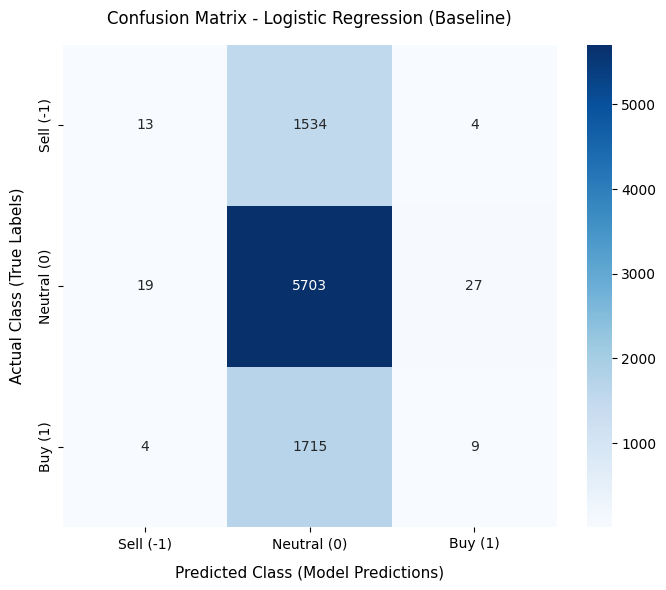

In [ ]:
# ---------------------------------------------------------
# Plotten van de Confusion Matrix voor Logistic Regression
# ---------------------------------------------------------
# --- GEWIJZIGD: labels en class_names aangepast naar de -1, 0, 1 logica ---
class_names = ['Sell (-1)', 'Neutral (0)', 'Buy (1)']

# Bereken de matrix met de juiste labels
cm_lr = confusion_matrix(all_true_labels_lr, all_pred_labels_lr, labels=[-1, 0, 1])

# Maak het figuur aan
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

# Titels en labels volgens de academische standaard
plt.title('Confusion Matrix - Logistic Regression (Baseline)', fontsize=12, pad=15)
plt.ylabel('Actual Class (True Labels)', fontsize=11, labelpad=10)
plt.xlabel('Predicted Class (Model Predictions)', fontsize=11, labelpad=10)

plt.tight_layout()

# Sla het figuur op om direct in je Word-document te kunnen plakken
plt.savefig('confusion_matrix_logistic_regression.png', dpi=300)
plt.show()

In [ ]:
# average score
print("\nAverage Accuracy:", np.mean(accuracy_list))
print("Average Macro F1:", np.mean(macro_f1_list))

# average classification report per class
avg_report = {}
classes = y_train.unique()
for cls in classes:
    avg_report[str(cls)] = {
        'precision': np.mean([r[str(cls)]['precision'] for r in report_list]),
        'recall': np.mean([r[str(cls)]['recall'] for r in report_list]),
        'f1-score': np.mean([r[str(cls)]['f1-score'] for r in report_list]),
        'support': np.mean([r[str(cls)]['support'] for r in report_list])
    }

avg_report_df = pd.DataFrame(avg_report).T
print("\nAverage Classification Report per class:")
print(avg_report_df)


Average Accuracy: 0.6341383446376037
Average Macro F1: 0.26746473390851905

Average Classification Report per class:
      precision    recall  f1-score  support
0.0    0.637063  0.991998  0.775864   1149.8
1.0    0.262210  0.005211  0.010189    345.6
-1.0   0.329221  0.008383  0.016341    310.2


In [ ]:
#Important features
all_coefs = []
accuracy_list = []
macro_f1_list = []
report_list = []

fold = 1
for train_index, val_index in skf.split(X_train_scaled, y_train):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_tr, y_tr)


    fold_coefs = np.mean(np.abs(model.coef_), axis=0)
    all_coefs.append(fold_coefs)

    y_pred = model.predict(X_val_fold)

    acc = accuracy_score(y_val_fold, y_pred)
    macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
    report = classification_report(y_val_fold, y_pred, output_dict=True)

    accuracy_list.append(acc)
    macro_f1_list.append(macro_f1)
    report_list.append(report)

    print(f"Fold {fold} - Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}")
    fold += 1

mean_coefs = np.mean(all_coefs, axis=0)


feature_names = X_train.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_coefs
}).sort_values(by='Importance', ascending=False)

# Top 20 features
print(feature_importance.head(20))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 - Accuracy: 0.3184, Macro F1: 0.3222


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 - Accuracy: 0.3073, Macro F1: 0.3131


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 - Accuracy: 0.2968, Macro F1: 0.3006


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 - Accuracy: 0.3053, Macro F1: 0.3012
Fold 5 - Accuracy: 0.3042, Macro F1: 0.3064
                                           Feature  Importance
51                       Sales/Stockholders Equity    0.004042
49                               Payables Turnover    0.003468
27                               Total Debt/EBITDA    0.001798
107                  Sales/Stockholders Equity_QoQ    0.001574
0                                     Surprise_Pct    0.001269
34              Free Cash Flow/Operating Cash Flow    0.001187
35         Total Liabilities/Total Tangible Assets    0.001074
36                      Long-term Debt/Book Equity    0.000932
124                          Price/Book_Regime_Low    0.000813
13   After-tax Return on Total Stockholders Equity    0.000719
11       After-tax Return on Average Common Equity    0.000719
44                                   Current Ratio    0.000683
96                 After-tax Interest Coverage_QoQ    0.000682
8                             

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
top_29_features = [
    "Surprise_Pct", "Sales/Stockholders Equity", "Payables Turnover",
    "Total Debt/EBITDA", "Sales/Stockholders Equity_QoQ",
    "Total Liabilities/Total Tangible Assets", "Long-term Debt/Book Equity",
    "Current Ratio", "Sales/Invested Capital", "Return on Equity",
    "Gross Profit/Total Assets", "Pre-tax Return on Total Earning Assets",
    "Effective Tax Rate", "Gross Profit Margin", "Interest/Average Long-term Debt",
    "Inventory Turnover", "Receivables/Current Assets",
    "Cash Conversion Cycle (Days)", "Total Debt/Capital",
    "Interest Coverage Ratio", "Receivables Turnover", "Asset Turnover"
]

X_train_29 = X_train[top_29_features]

imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_29)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_list = []
macro_f1_list = []
report_list = []

print("Start Cross-Validation op de 29 Feature Set...")

fold = 1
for train_index, val_index in skf.split(X_train_scaled, y_train):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val_fold)

    acc = accuracy_score(y_val_fold, y_pred)
    macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
    report = classification_report(y_val_fold, y_pred, output_dict=True, zero_division=0)

    accuracy_list.append(acc)
    macro_f1_list.append(macro_f1)
    report_list.append(report)

    print(f"Fold {fold} - Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}")
    fold += 1



Start Cross-Validation op de 29 Feature Set...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 - Accuracy: 0.6346, Macro F1: 0.2667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 - Accuracy: 0.6379, Macro F1: 0.2677


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 - Accuracy: 0.6312, Macro F1: 0.2619


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 - Accuracy: 0.6371, Macro F1: 0.2732
Fold 5 - Accuracy: 0.6349, Macro F1: 0.2608


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# average score
print("\nAverage Accuracy:", np.mean(accuracy_list))
print("Average Macro F1:", np.mean(macro_f1_list))

# average classification report per class
avg_report = {}
classes = y_train.unique()
for cls in classes:
    avg_report[str(cls)] = {
        'precision': np.mean([r[str(cls)]['precision'] for r in report_list]),
        'recall': np.mean([r[str(cls)]['recall'] for r in report_list]),
        'f1-score': np.mean([r[str(cls)]['f1-score'] for r in report_list]),
        'support': np.mean([r[str(cls)]['support'] for r in report_list])
    }

avg_report_df = pd.DataFrame(avg_report).T
print("\nAverage Classification Report per class:")
print(avg_report_df)


Average Accuracy: 0.6351353291429309
Average Macro F1: 0.2660481384062663

Average Classification Report per class:
      precision    recall  f1-score  support
0.0    0.637236  0.994260  0.776683   1149.8
1.0    0.336061  0.005789  0.011339    345.6
-1.0   0.310476  0.005159  0.010123    310.2


In [ ]:
test = pd.read_parquet("test_feature_engineered.parquet")

In [ ]:
valuation_features = [
    'Shillers Cyclically Adjusted P/E Ratio',
    'Enterprise Value Multiple',
    'Price/Book',
    'Price/Sales',
    'Price/Cash flow',
    'Price/Operating Earnings (Basic, Excl. EI)',
    'Price/Operating Earnings (Diluted, Excl. EI)',
    'P/E (Diluted, Incl. EI)',
    'P/E (Diluted, Incl. EI)',
    'Trailing P/E to Growth (PEG) ratio',
    'Book/Market',
    'Dividend Yield',
    'Dividend Payout Ratio'
]

regime_cols = [f"{col}_Regime" for col in valuation_features if f"{col}_Regime" in train.columns]

for col in regime_cols:
    test[col] = test[col].astype(str)
    test[col] = test[col].replace("nan", "Missing")

test = pd.get_dummies(test, columns=regime_cols, drop_first=True)

test = test.reindex(columns=train.columns, fill_value=0)

conditions_test = [
    (test['Return'] > 3),
    (test['Return'] >= -3) & (test['Return'] <= 3),
    (test['Return'] < -3)
]

choices = [1, 0, -1]

test['Return_class_3'] = np.select(conditions_test, choices, default=np.nan)

X_test = test.drop(columns=[
    "Return","Return_class","EPS_Estimate","EPS_Actual",
    "Close_Before","Open_After","Return_class_3"
])

y_test = test["Return_class_3"]

drop_cols = [
    'CUSIP',
    'Global Company Key',
    'Historical CRSP PERMNO Link to COMPUSTAT Record',
    'Ticker',
    'Date',
    'EarningsDate',
    'Fiscal year end',
    'Fiscal quarter end',
    'Year',
    'Month'
]

X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

from sklearn.impute import SimpleImputer

X_test_scaled = imputer.transform(X_test)

In [ ]:
y_test_pred = model.predict(X_test_scaled)

In [ ]:
print("===== TEST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Macro F1:", f1_score(y_test, y_test_pred, average='macro'))
print(classification_report(y_test, y_test_pred))

===== TEST RESULTS =====
Accuracy: 0.4148606811145511
Macro F1: 0.20400640228442393
              precision    recall  f1-score   support

        -1.0       0.20      0.01      0.02       352
         0.0       0.42      0.98      0.59       540
         1.0       0.50      0.01      0.01       400

    accuracy                           0.41      1292
   macro avg       0.37      0.33      0.20      1292
weighted avg       0.38      0.41      0.25      1292



In [ ]:
# McNemar test
overzicht_lr = pd.DataFrame({
    'Echte Waarde': all_true_labels_lr,
    'Verwachte Waarde': all_pred_labels_lr,
    'Resultaat': ['GOED' if echte == verwacht else 'FOUT' for echte, verwacht in zip(all_true_labels_lr, all_pred_labels_lr)]
})

print(overzicht_lr.head(20))
overzicht_lr.to_csv('overzicht_lr_resultaten.csv', index=False)

    Echte Waarde  Verwachte Waarde Resultaat
0              0                 0      GOED
1              0                 0      GOED
2              0                 0      GOED
3              0                 0      GOED
4              0                 0      GOED
5              0                 0      GOED
6              0                 0      GOED
7              0                 0      GOED
8              1                 0      FOUT
9              0                 0      GOED
10            -1                 0      FOUT
11            -1                 0      FOUT
12             0                 0      GOED
13             0                 0      GOED
14             0                 0      GOED
15             0                 0      GOED
16             0                 0      GOED
17             0                 0      GOED
18             0                 0      GOED
19             0                 0      GOED


In [ ]:
#MCNemar
final_lr_model = LogisticRegression(max_iter=1000, random_state=42)
final_lr_model.fit(X_train_scaled, y_train)

y_test_pred_lr = final_lr_model.predict(X_test_scaled)

overzicht_lr_test = pd.DataFrame({
    'Echte Waarde': y_test.astype(int),
    'Verwachte Waarde': y_test_pred_lr.astype(int),
    'Resultaat': ['GOED' if echte == verwacht else 'FOUT' for echte, verwacht in zip(y_test, y_test_pred_lr)]
})
overzicht_lr_test.to_csv('overzicht_lr_resultaten_v2.csv', index=True) # index=True helpt bij het matchen!

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
